# Laptop Price Prediction Analysis

This notebook presents a comprehensive analysis and machine learning pipeline for predicting laptop prices according to their features.

 # About Dataset

The dataset emulates laptop prices, capturing various features commonly associated with laptops and their corresponding simulated prices. The dataset encompasses key attributes such as brand, processor speed, RAM size, storage capacity, screen size, and weight.

Citation for original work: https://www.kaggle.com/datasets/mrsimple07/laptoppriceprediction


## Laptop Price Prediction Project
## Data Ingestion
**Objective:** Load the dataset and import necessary libraries for analysis.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

## Data Exploration & Cleaning
**Objective:** Perform Initial Data Analysis (IDA) to understand the dataset's structure, identify missing values, duplicates, and statistical properties.

In [ ]:
data = pd.read_csv("Laptop_price.csv")

In [9]:
data.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718


**Insight:** The dataset includes columns such as Brand, Processor Speed, RAM Size, Storage Capacity, and Price.


In [ ]:
data.shape

In [11]:
data["Brand"].nunique()

5

In [13]:
data.isna().sum()

Brand               0
Processor_Speed     0
RAM_Size            0
Storage_Capacity    0
Screen_Size         0
Weight              0
Price               0
dtype: int64

**Insight:** Checking for missing values ensures data quality. If no missing values are found, the dataset is clean for this check.

In [ ]:
data.duplicated().sum()

In [15]:
data.describe()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,584.576000,14.056790,3.466919,19604.187963
std,0.731796,10.988665,313.438517,1.705882,0.866541,9406.064880
min,1.511580,4.000000,256.000000,11.012111,2.000560,8570.012950
25%,2.089246,8.000000,256.000000,12.635523,2.717211,10114.012948
50%,2.760885,16.000000,512.000000,14.099643,3.464630,17287.241878
75%,3.362610,32.000000,1000.000000,15.528590,4.212583,31566.214754
max,3.998534,32.000000,1000.000000,16.985737,4.990728,33503.935037


**Section Summary:** The exploration phase confirmed the dataset dimensions and data types. We verified there are no missing or duplicate records. Statistical summaries provided an overview of the distribution of numerical features.

## Data Visualization
**Objective:** Use graphical representations to discover patterns, correlations, and distributions within the data.

In [ ]:
numeric_data = data.select_dtypes(include=["number"])

In [18]:
numeric_data.corr()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
Processor_Speed,1.000000,0.021391,-0.067576,-0.013425,-0.054603,-0.050737
RAM_Size,0.021391,1.000000,0.002111,-0.036002,-0.025382,0.061237
Storage_Capacity,-0.067576,0.002111,1.000000,-0.027560,0.041335,0.997908
Screen_Size,-0.013425,-0.036002,-0.027560,1.000000,0.021995,-0.026740
Weight,-0.054603,-0.025382,0.041335,0.021995,1.000000,0.038417
Price,-0.050737,0.061237,0.997908,-0.026740,0.038417,1.000000


**Insight:** The correlation matrix helps identify which features (Processor Speed, RAM, Storage) have the strongest linear relationship with the target variable, Price.

In [ ]:
data.groupby("Brand")["Price"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Price of Laptops by Brand")
plt.ylabel("Average Price")
plt.show()

**Insight:** This bar chart shows the average price across different laptop brands, highlighting which brands command a premium in the market.

In [ ]:
data.groupby("RAM_Size")["Brand"].value_counts().reset_index()

In [32]:
data["Brand"].value_counts()

Brand
Dell      210
Asus      206
Acer      204
Lenovo    190
HP        190
Name: count, dtype: int64

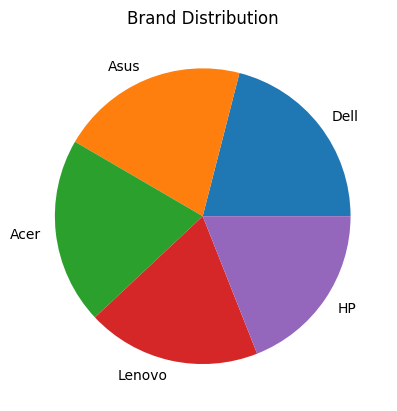

In [31]:
data["Brand"].value_counts().sort_values(ascending=False).plot(kind="pie")
plt.title("Brand Distribution")
plt.ylabel("")
plt.show()

**Section Summary:** Visualization revealed how brand and hardware specifications influence pricing. We observed the distribution of brands and their respective average prices.

## Data Preparation
**Objective:** Select relevant features for the model and split the dataset into training and testing sets to evaluate performance.

In [ ]:
data.columns

In [ ]:
y = data["Price"]
X = data[["Processor_Speed","RAM_Size", "Storage_Capacity"]]

**Insight:** We are using hardware specs (Processor Speed, RAM, Storage) as predictors for the laptop Price.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

**Section Summary:** Data was split into features (X) and target (y), with 20% of the data reserved for testing.


## Model Development & Hyperparameter Tuning
**Objective:** Train a Random Forest Regressor and optimize its performance using Grid Search cross-validation.


In [40]:
from sklearn.ensemble import RandomForestRegressor

In [41]:
rfrmodel = RandomForestRegressor()

In [42]:
from sklearn.model_selection import GridSearchCV

In [43]:
param_gridrfr = {"max_depth": [2 ,5 ,10 ,15, 20, 25],
                 "max_features": ["auto", "log2"],
                 "n_estimators": [2, 4, 6, 8, 10, 12]}

In [44]:
gridrfr = GridSearchCV(rfrmodel, param_gridrfr)

In [ ]:
gridrfr.fit(X_train, y_train)
gridrfr.best_params_

In [ ]:
predictions = gridrfr.predict(X_test)

**Insight:** The Grid Search identifies the optimal combination of depth, features, and estimators for the Random Forest model.


## Model Evaluation
**Objective:** Measure the accuracy of the predictions using standard regression metrics.


In [ ]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, predictions)

**Insight:** The Mean Absolute Error (MAE) tells us, on average, how far our predictions are from the actual laptop prices. Comparing this to the price distribution gives context to the model's accuracy.

In [ ]:
data["Price"].describe()

**Section Summary:** The model was evaluated on unseen test data. The MAE indicates the average prediction error, providing a clear metric for model performance.


## Model Persistence
**Objective:** Save the trained model to a file for later use in production or further analysis.


In [53]:
X

,Processor_Speed,RAM_Size,Storage_Capacity
0,3.830296,16,512
1,2.912833,4,1000
2,3.241627,4,256
3,3.806248,16,512
4,3.268097,32,1000
...,...,...,...
995,3.343584,4,1000
996,2.780555,8,256
997,3.200569,4,512
998,1.604182,8,256


In [54]:
X.columns

Index(['Processor_Speed', 'RAM_Size', 'Storage_Capacity'], dtype='str')

In [55]:
import joblib
joblib.dump(gridrfr, "rf_model.pkl")

['rf_model.pkl']

**Section Summary:** The final model was exported as `rf_model.pkl`, enabling it to be loaded and used without retraining.